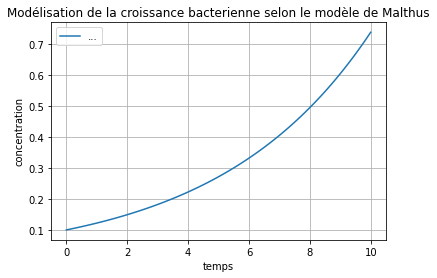

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation
rmax = 0.2 # taux de croissance maximal (h⁻¹)
C0 = 0.1 # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)

# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)
# Tracé du graphique
plt.title('Modélisation de la croissance bacterienne selon le modèle de Malthus') # Titre du graphique
plt.plot(time, C, label='...') # Nom de la courbe
plt.xlabel('temps') # Axe des X
plt.ylabel('concentration') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
c'est une courbe exponentielle.        
la population double vers 3,5heures 


A rmax=0.4, la croissance est plus abrupte (rapide).
à rmax=0.1, croissance linéaire.
à rmax=0, la concentration n'augmente pas.
à rmax=-0.1, on observe une décroissance.

les limites de ce modéle sont la limite des ressources, la mortalité et la compétition. 

Pour le rendre plus réalise, ajouter une capacité limite de milieu, la mortalité et des contraintes environnementales ce qui conduit à un modèle sigmoïde.


In [ ]:
question 2) ![image-2.png](attachment:image-2.png)

question 7) 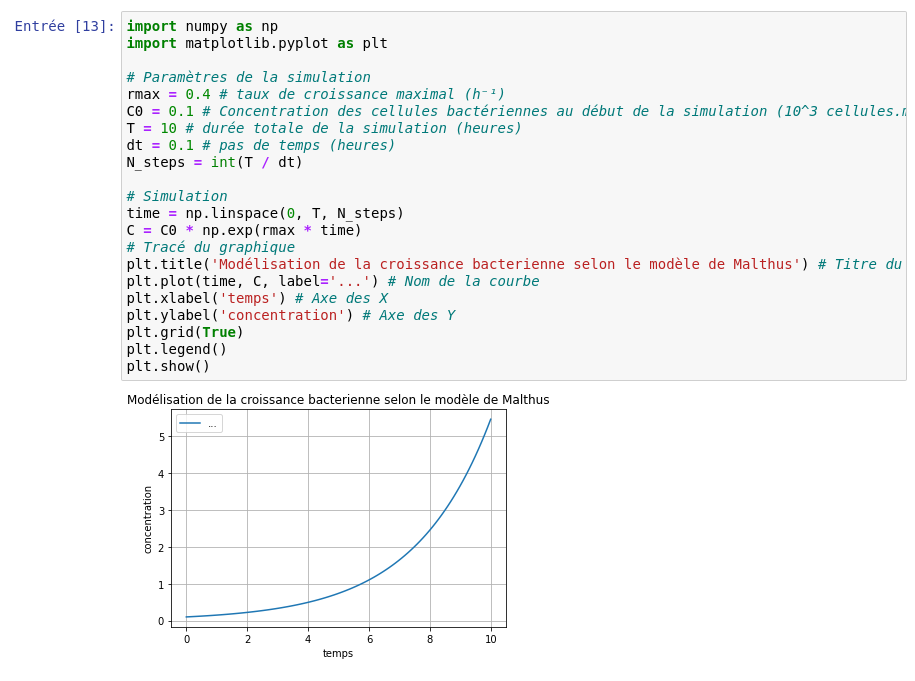
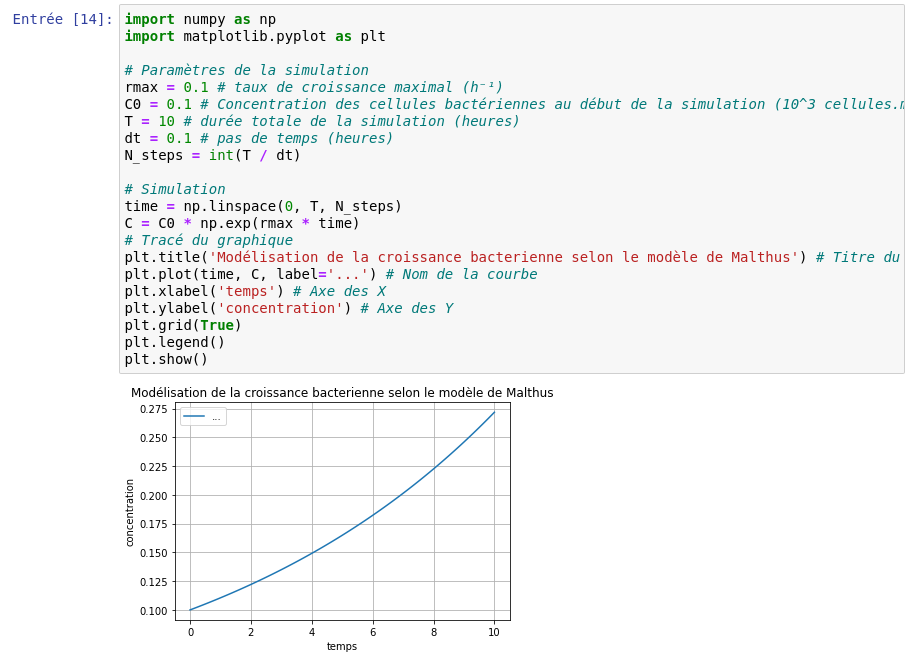
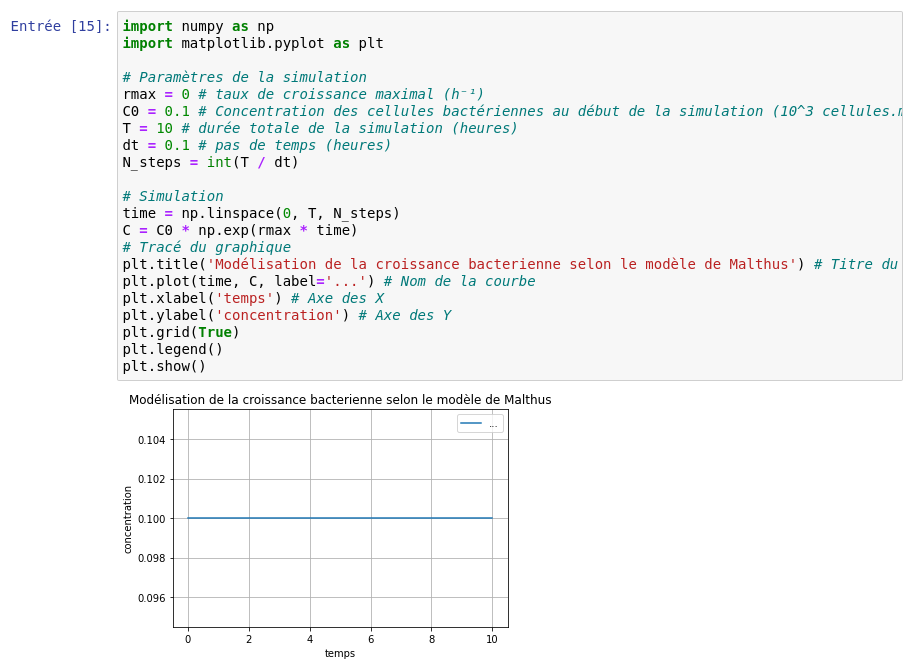
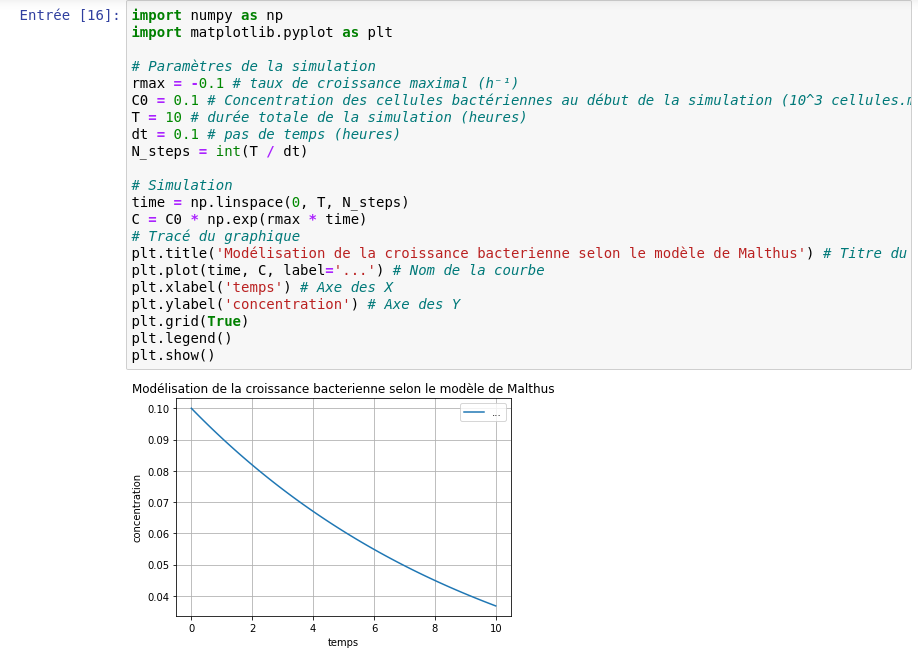

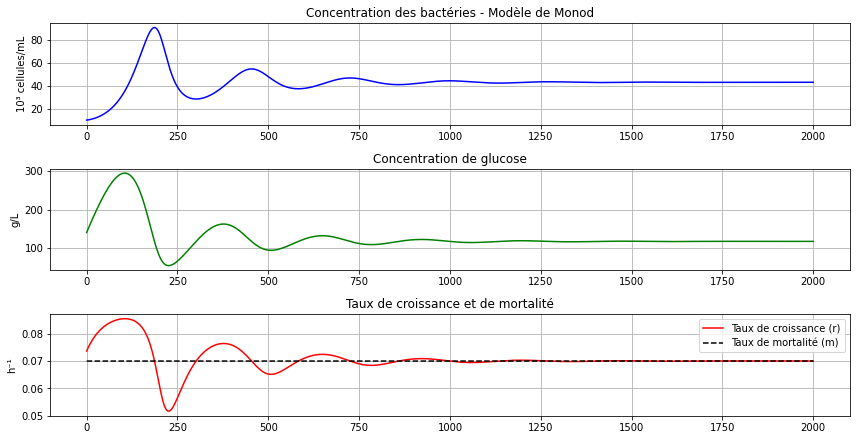

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 2000          # Durée totale (heures)
dt = 0.1          # Pas de temps (heures)
N_steps = int(T / dt)  # Nombre de pas de temps

# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10       # Taux de croissance maximal (h⁻¹)
K = 50           # Affinité pour le substrat (g/L)
m0 = 0.07         # Taux de mortalité minimal (h⁻¹)
C0 = 10 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 140  # Concentration initiale de glucose (g/L)
glucose_inflow = 3      # Flux entrant de glucose (g/L/h)

# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps)          # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])

    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r - m0) * C[i-1]

    # Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt

    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0

# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)

# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))

# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)

# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--')  # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend()  # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()


les courbes ont une tendance à diminuer au bout d'un certain temps, et c'est aussi du a la taille de la population bacterienne qui consomme plus de glucose ce qui affaiblit cette ressource, moins il y a de glucose, plus les bactéries meurent et cela fait augmenter la courbe de mortalité et diminuer la courbe de croissance. La croissance des bactéries s'écroule au moment où la concentration du glucose diminue, ce qui fait que le facteur limitant est le glucose. 

r atteint son max à r=m. m= 0.07/h, r= 0.07/h.

K= rmax/2= 0.10/2= 0.05 => K= 50g/L. 

Pour que cette popûlation se maintienne, il faut un taux de glucose croissant pour subvenir aux besoins nutritifs de toutes les bactéries présentes dans la colonie.

on observe sur chacun des graphiques des fluctuations.

la population bacterienne présente des fluctuations marquées car elle varie en fonction de la quantité de glucose présent dans le milieu, si du glucose est consommé, il y aura une diminution de la taille et de la croissance de la population.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.06      # Taux de mortalité de base (souche 1)
K_1 = 800        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.06      # Taux de mortalité de base (souche 2)
K_2 = 650      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()


Les deux souches augmentent au début, car le glucose est abondant. Ensuite, elles présentent des oscillations. La souche 2 atteint des valeurs beaucoup plus élevées que la souche 1, puis se stabilise. La souche 1 diminue fortement et reste presque nulle.

Le glucose chute fortement au début car les deux souches le consomment rapidement. Ensuite, il remonte puis oscille avant de se stabiliser.


La souche 2 garde un taux de croissance plus élevé que la souche 1, car son K est plus faible. Elle utilise donc mieux le glucose. La mortalité est identique pour les deux souches.
2. Résultat de la concurrence

La souche 2 l’emporte sur la souche 1.

K_2 = 650 < K_1 = 800

la souche 2 a une meilleure affinité pour le glucose. Elle exploite mieux la ressource limitante, donc elle se développe davantage et prend le dessus.

La souche 1 est presque éliminée par compétition.

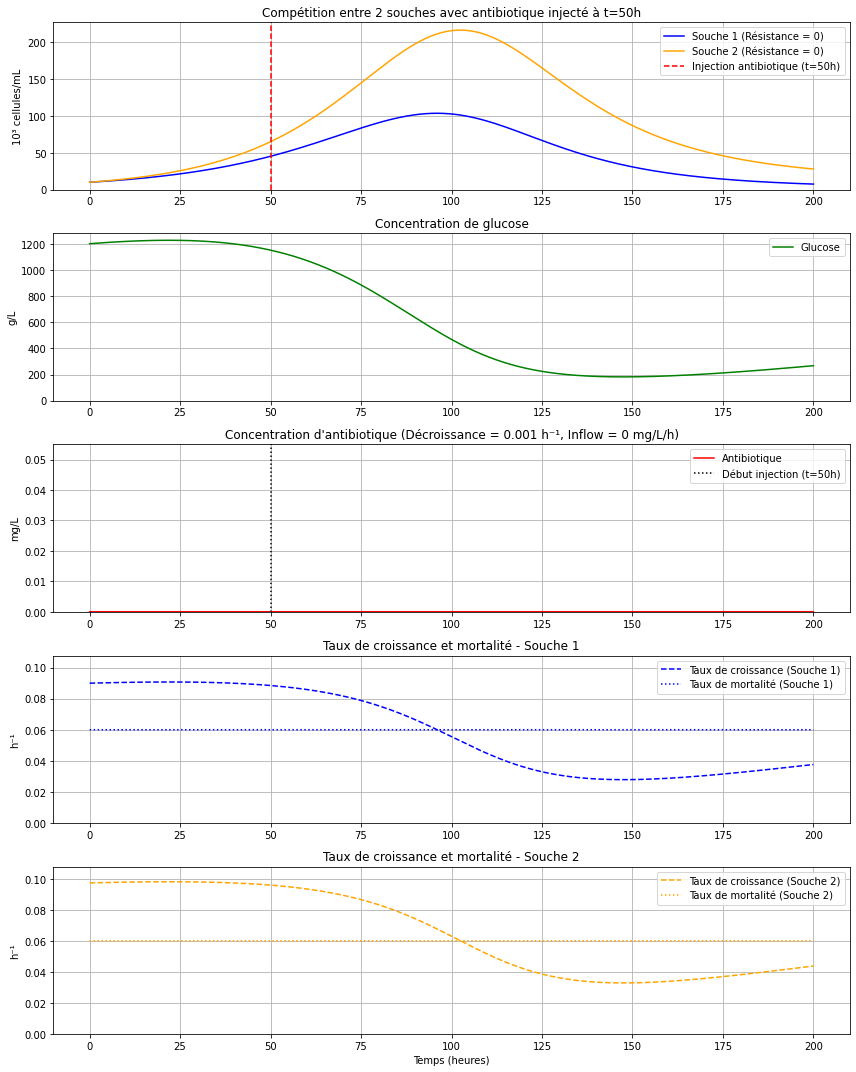

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.06        # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0  # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.06        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 4      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 00   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.001    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 200         # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=50h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()


La souche 2 augmente fortement et a des pics plus élevés que la souche 1. Elle domine ensuite la population. La souche 1 augmente au début, puis chute et reste nulle.
C'est dû fait que la souche 2 aune meilleure affinité pour le glucose : son K est plus faible, donc elle utilise mieux le substrat limitant. Le glucose chute au début car il est consommé massivement, puis il oscille avant de se stabiliser.
la sélection favorise surtout la souche 2 grâce à sa meilleure exploitation du glucose, pas grâce à l’antibiotique.

Quand l’antibiotique est injecté à t = 50, la mortalité des deux souches augmente, car elles ont toutes les deux une résistance nulle.
La population des deux souches diminue davantage après l’injection. Cependant, comme la souche 2 utilise mieux le glucose, elle garde un avantage. L’antibiotique réduit les populations, mais ne choisit pas une souche résistante. 

La souche 1 devient totalement résistante. L’antibiotique n’augmente donc plus sa mortalité. La souche 2, elle, reste sensible.
Même si la souche 1 utilise moins bien le glucose, elle est protégée contre l’antibiotique. Elle peut donc se maintenir, voire devenir dominante, car la souche 2 est fortement pénalisée par l’antibiotique.
l’antibiotique inverse la sélection : il favorise la souche résistante.
    
La souche 1 est seulement faiblement résistante. Elle subit encore l’effet de l’antibiotique, mais moins que la souche 2.
La souche 2 garde son avantage sur le glucose, mais cet avantage est réduit par sa sensibilité à l’antibiotique. La souche 1 survit donc mieux qu’avant, mais elle ne devient pas forcément totalement dominante.
une faible résistance améliore la survie de la souche 1, mais l’équilibre dépend de l’intensité de l’antibiotique et de l’avantage de la souche 2 sur le glucose.

L’antibiotique arrive en continu dans le milieu. La pression de sélection devient durable.
Les souches sensibles sont constamment pénalisées. Une souche résistante, même faiblement, devient progressivement avantagée sur le long terme. Cette situation est plus dangereuse biologiquement car elle favorise le maintien et la sélection des résistances.

L’antibiotique agit donc comme une pression de sélection qui modifie le devenir des populations bactériennes.

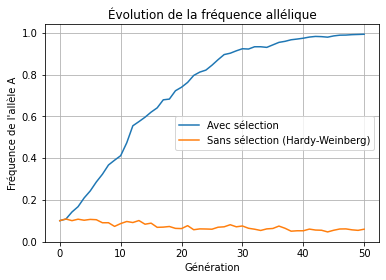

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation
TAILLE_POP = 1000
GENERATIONS = 50

# Fréquence initiale de l'allèle A
freq_A_initiale = 0.1

# Valeurs sélectives (fitness)
# Cas 1 : sélection (ex : antibiotique ou stress)
fitness_selection = {"AA": 1.0,
                     "Aa": 0.9,
                     "aa": 0.7}
# Cas 2 : pas de sélection (équilibre de Hardy-Weinberg)
fitness_neutre = {"AA": 1.0,
                  "Aa": 1.0,
                  "aa": 1.0}

# Génération d'une population
def generer_population(freq_A, taille):
    freq_a = 1 - freq_A
    probabilites = [
        freq_A ** 2,          # AA
        2 * freq_A * freq_a,  # Aa
        freq_a ** 2           # aa
    ]
    return np.random.choice(["AA", "Aa", "aa"], size=taille, p=probabilites)

# Calcul de la fréquence allélique
def calcul_freq_A(population):
    nb_A = sum(genotype.count("A") for genotype in population)
    return nb_A / (2 * len(population))

# Application de la sélection
def appliquer_selection(population, fitness):
    poids = [fitness[g] for g in population]
    total = sum(poids)
    probabilites = [p / total for p in poids]
    return np.random.choice(population, size=len(population), p=probabilites)

# Simulation de l'évolution
def simuler(fitness):
    freq_A = freq_A_initiale
    frequences = [freq_A]  # Initialisation de la liste
    population = generer_population(freq_A, TAILLE_POP)
    for i in range(GENERATIONS):
        population = appliquer_selection(population, fitness)
        freq_A = calcul_freq_A(population)
        population = generer_population(freq_A, TAILLE_POP)
        frequences.append(freq_A)
    return frequences

# Lancement des simulations
freq_selection = simuler(fitness_selection)
freq_neutre = simuler(fitness_neutre)

# Tracé des courbes
plt.figure()
plt.plot(freq_selection, label="Avec sélection")
plt.plot(freq_neutre, label="Sans sélection (Hardy-Weinberg)")
plt.xlabel("Génération")
plt.ylabel("Fréquence de l'allèle A")
plt.title("Évolution de la fréquence allélique")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
courbe bleue: l'allèle A confère un avantage sélectif. donc sa fréquence augmente rapidement sur les 50ans pour s'approcher de 1.
courbe orange: tous les génotypes ont à peu près la meme valeur sélective. La fréquence de l'allèle a reste globalement aux alentours de la fréquence initiale. les légères fluctuations peuvent être dues à la dérive génétique. 